# ML Challenge 

<img src="https://imageio.forbes.com/specials-images/imageserve/5ecd179f798e4c00060d2c7c/0x0.jpg?format=jpg&height=600&width=1200&fit=bounds" width="500" height="300">

In the bustling city of Financia, the Central Lending Institution (CLI) is the largest provider of loans to individuals and businesses. With a mission to support economic growth and financial stability, CLI processes thousands of loan applications every month. However, the traditional manual review process is time-consuming and prone to human error, leading to delays and inconsistencies in loan approvals.
To address these challenges, CLI has decided to leverage the power of machine learning to streamline their loan approval process. They have compiled a comprehensive dataset containing historical loan application records, including various factors such as credit scores, income levels, employment status, loan terms(measured in years), loan amounts, asset values, and the final loan status (approved or denied).


**Your task is to develop a predictive model that can accurately determine the likelihood of loan approval based on the provided features. By doing so, you will help CLI make faster, more accurate, and fairer lending decisions, ultimately contributing to the financial well-being of the community.**

It is recommended that you follow the typical machine learning workflow, though you are not required to strictly follow each steps: 
1. Data Collection: Gather the data you need for your model. (Already done for you)

2. Data Preprocessing: Clean and prepare the data for analysis. (Already done for you)

3. Exploratory Data Analysis (EDA): Understand the data and its patterns. (Partially done for you)

4. Feature Engineering: Create new features or modify existing ones to improve model performance. (Partially done for you)

5. Model Selection: Choose the appropriate machine learning algorithm.

6. Model Training: Train the model using the training dataset.

7. Model Evaluation: Evaluate the model's performance using a validation dataset.

8. Model Optimization: Optimize the model's parameters to improve performance.

9. Model Testing: Test the final model on a separate test dataset.

**Please include ALL your work and thought process in this notebook**

In [1]:
# You may include any package you deem fit. We sugggest looking into Scikit-learn
import pandas as pd

## Dataset


In [2]:
# DO NOT MODIFY
loan_data = pd.read_csv("../../data/loan_approval.csv")


## EDA
Uncomment to see desired output. Add more analysis if you like

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')
           loan_id  no_of_dependents  income_annum   loan_amount    loan_term  \
count  4269.000000       4269.000000  4.269000e+03  4.269000e+03  4269.000000   
mean   2135.000000          2.498712  5.059124e+06  1.513345e+07    10.900445   
std    1232.498479          1.695910  2.806840e+06  9.043363e+06     5.709187   
min       1.000000          0.000000  2.000000e+05  3.000000e+05     2.000000   
25%    1068.000000          1.000000  2.700000e+06  7.700000e+06     6.000000   
50%    2135.000000          3.000000  5.100000e+06  1.450000e+07    10.000000   
75%    3202.000000          4.000000  7.500000e+06  2.150000e+07    16.000000   
max    4269.000000          5.000000  9.900000e+06  3.950000e+07    20.

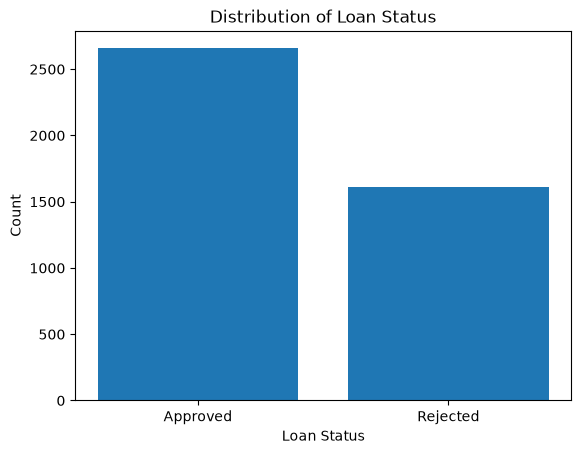

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


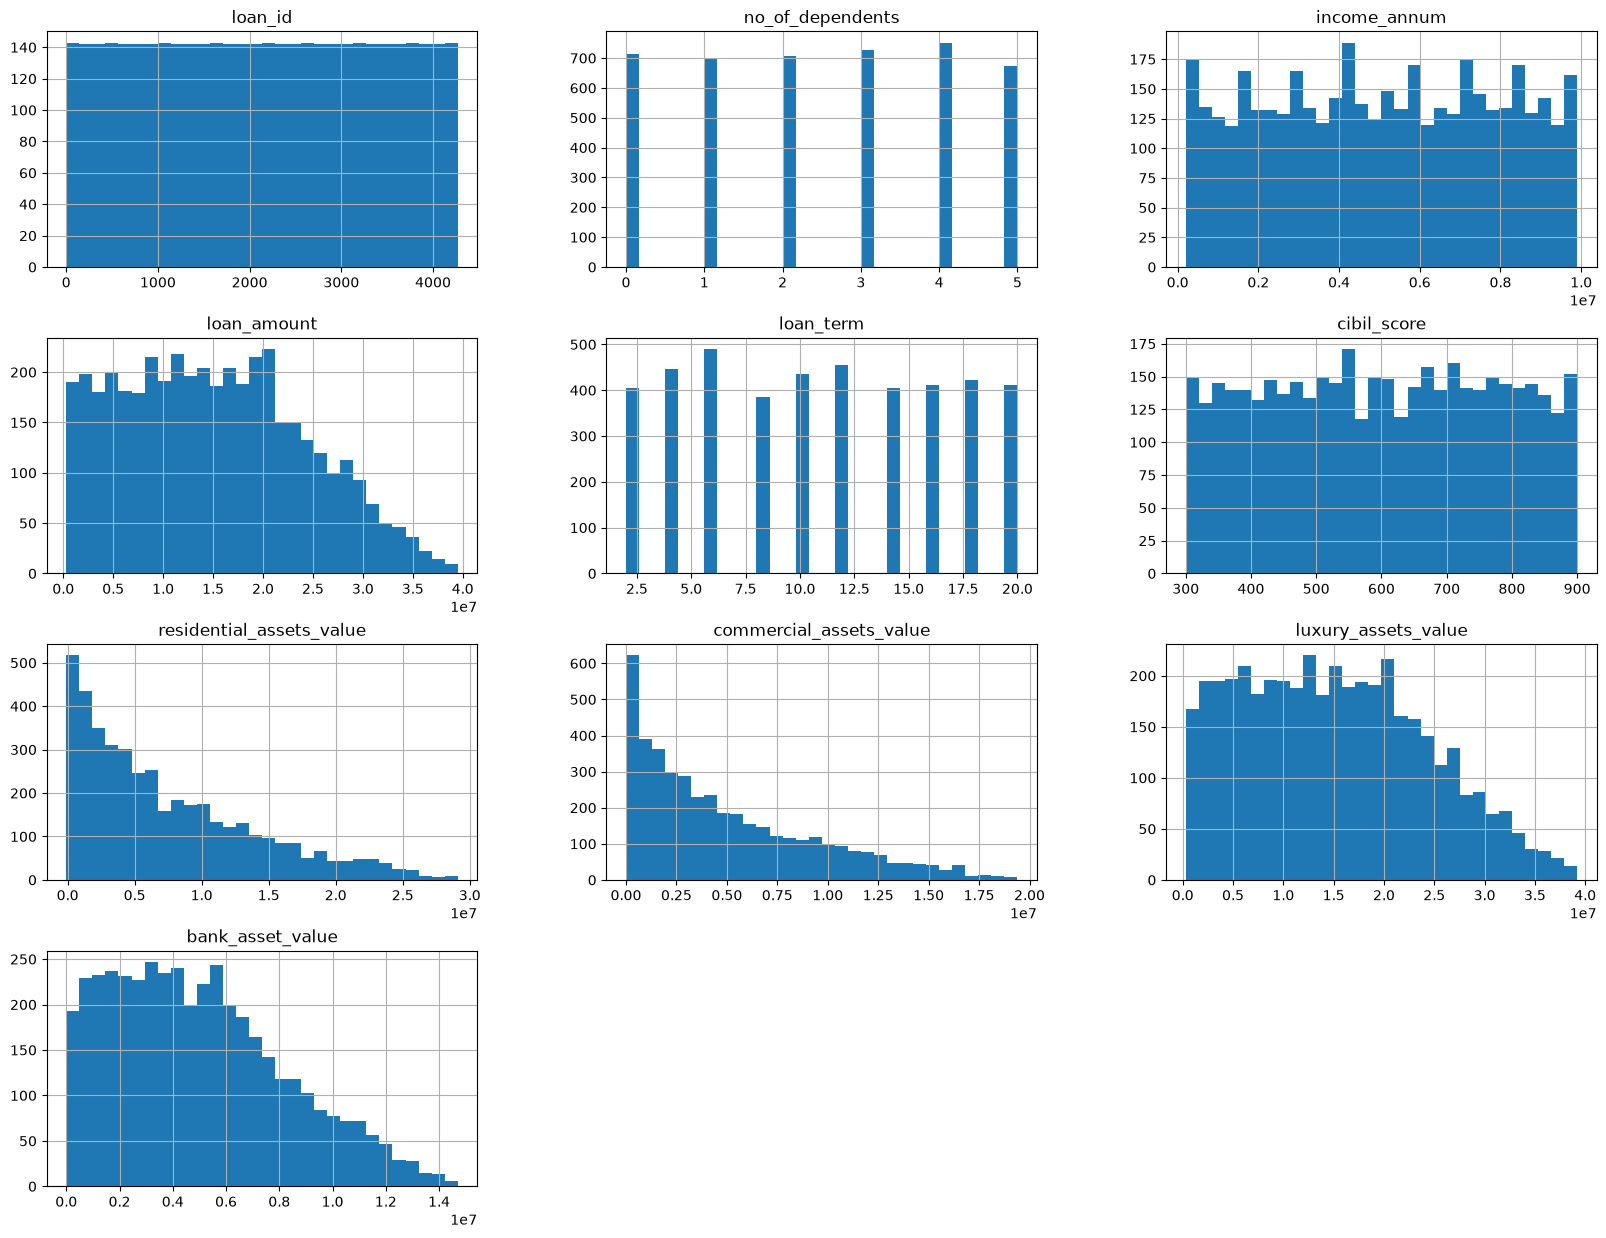

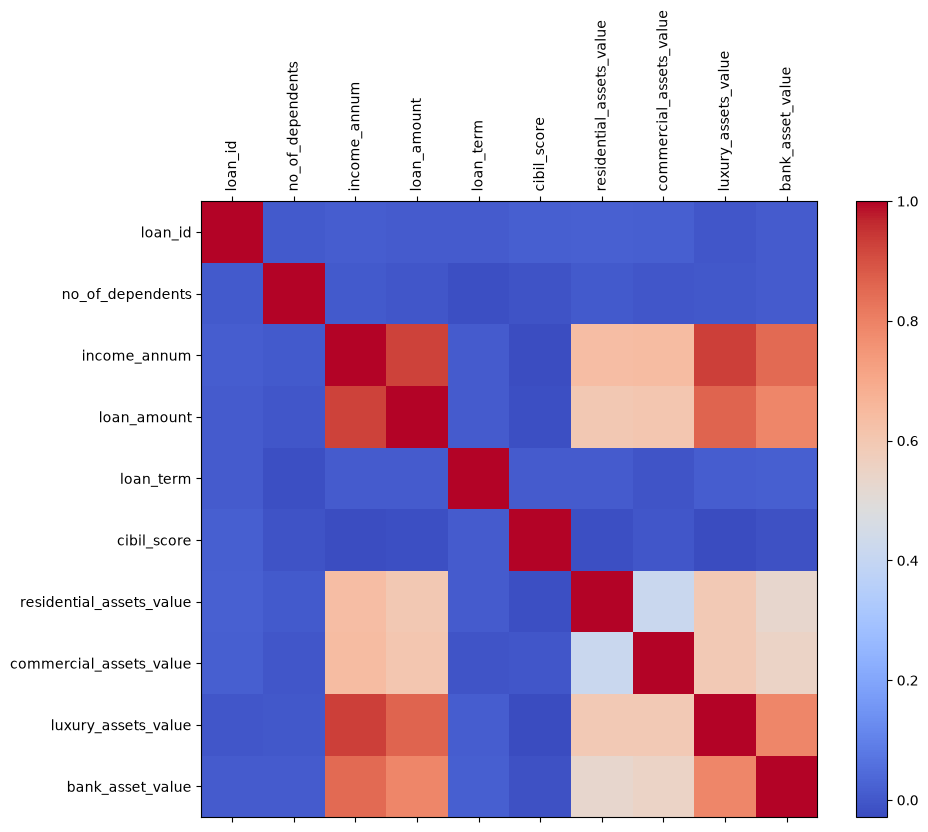

loan_status
Approved    703.461973
Rejected    429.468072
Name: cibil_score, dtype: float64


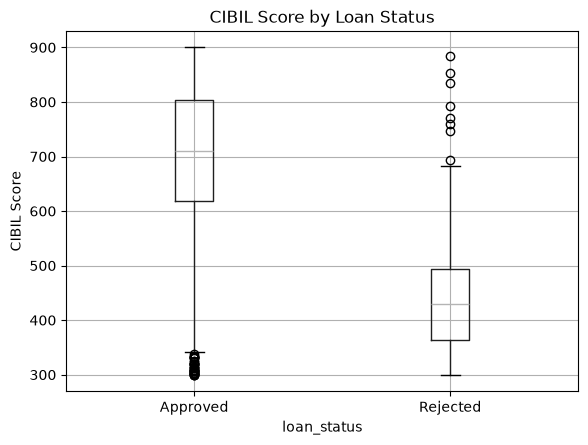

In [3]:
import matplotlib.pyplot as plt

# ------ Display basic information ------
print(loan_data.columns)
print(loan_data.describe())
print(loan_data.head())

# ------ Check for missing values ------
print(loan_data.isnull().sum())

# ------ Visualize the distribution of loan status ------
loan_status_counts = loan_data['loan_status'].value_counts()
plt.figure()
plt.bar(loan_status_counts.index, loan_status_counts.values)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

# more approved than rejected, not super imbalanced though
print(loan_status_counts)

# ------ Visualize the distribution of numerical features ------ 
loan_data.hist(bins=30, figsize=(20, 15))
plt.show()

# ------ Correlation matrix ------
# numeric_only because education / self_employed / loan_status are still strings here
corr_matrix = loan_data.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.show()

# cibil score looks like it might be the main thing
print(loan_data.groupby('loan_status')['cibil_score'].mean())
loan_data.boxplot(column='cibil_score', by='loan_status')
plt.title('CIBIL Score by Loan Status')
plt.suptitle('')
plt.ylabel('CIBIL Score')
plt.show()

## Feature Engineering

You may want to convert categorical variables to numerical. For example, education takes on the value Graduate and Not Graduate. But we want it to be 0 or 1 for machine learning algorithms to use.

In [4]:
loan_data['education'] = loan_data['education'].map({'Graduate': 1, 'Not Graduate': 0})
# Hint: Other categorical variables are self_employed and loan_status
loan_data['self_employed'] = loan_data['self_employed'].map({'Yes': 1, 'No': 0})
loan_data['loan_status'] = loan_data['loan_status'].map({'Approved': 1, 'Rejected': 0})

# raw loan amount is mostly just "rich people borrow more"
# so I also want how big the loan is compared to income
loan_data['loan_to_income'] = loan_data['loan_amount'] / loan_data['income_annum']

# combined asset value, in case the model cares about overall wealth
loan_data['total_assets'] = (
    loan_data['residential_assets_value']
    + loan_data['commercial_assets_value']
    + loan_data['luxury_assets_value']
    + loan_data['bank_asset_value']
)

print(loan_data.head())
print(loan_data.corr(numeric_only=True)['loan_status'].sort_values(ascending=False))

   loan_id  no_of_dependents  education  self_employed  income_annum  \
0        1                 2          1              0       9600000   
1        2                 0          0              1       4100000   
2        3                 3          1              0       9100000   
3        4                 3          1              0       8200000   
4        5                 5          0              1       9800000   

   loan_amount  loan_term  cibil_score  residential_assets_value  \
0     29900000         12          778                   2400000   
1     12200000          8          417                   2700000   
2     29700000         20          506                   7100000   
3     30700000          8          467                  18200000   
4     24200000         20          382                  12400000   

   commercial_assets_value  luxury_assets_value  bank_asset_value  \
0                 17600000             22700000           8000000   
1                  2

## Model Selection

You are free to use any classification machine learning models you like: Logistic Regression, Decision Trees/Random Forests, Support Vector Machines, KNN ... 

In [5]:
# logistic regression as a simple baseline, random forest as the actual model
# RF should be able to use the cibil score split without me scaling all the money columns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=2000)
rf = RandomForestClassifier(random_state=42)

## Model Training and Evaluation

In [6]:
# loan_id is just a row number so I'm dropping it
features = [
    'no_of_dependents', 'education', 'self_employed',
    'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
    'residential_assets_value', 'commercial_assets_value',
    'luxury_assets_value', 'bank_asset_value',
    'loan_to_income', 'total_assets'
]
X = loan_data[features]
y = loan_data['loan_status']

# hold out a test set and don't touch it until the end
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# split training again so I can compare models without leaking the test set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(X_tr.shape, X_val.shape, X_test.shape)

# scale for logistic regression, otherwise income/loan amount dominate
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)

log_reg.fit(X_tr_s, y_tr)
rf.fit(X_tr, y_tr)

print("logreg val acc:", accuracy_score(y_val, log_reg.predict(X_val_s)))
print("rf val acc:", accuracy_score(y_val, rf.predict(X_val)))
print("\nrandom forest on val set:")
print(classification_report(y_val, rf.predict(X_val), target_names=['Rejected', 'Approved']))

(2732, 13) (683, 13) (854, 13)


logreg val acc: 0.8887262079062958
rf val acc: 0.9970717423133236

random forest on val set:
              precision    recall  f1-score   support

    Rejected       1.00      0.99      1.00       258
    Approved       1.00      1.00      1.00       425

    accuracy                           1.00       683
   macro avg       1.00      1.00      1.00       683
weighted avg       1.00      1.00      1.00       683



## Model Optimization and Testing

best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
cv acc: 0.9959002670921212

test acc: 0.9953161592505855
[[319   4]
 [  0 531]]
              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       323
    Approved       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      0.99      1.00       854
weighted avg       1.00      1.00      1.00       854

cibil_score                 0.797878
loan_term                   0.069789
loan_to_income              0.044899
loan_amount                 0.014419
total_assets                0.012457
commercial_assets_value     0.011445
luxury_assets_value         0.011051
residential_assets_value    0.010880
income_annum                0.009786
bank_asset_value            0.009772
no_of_dependents            0.004883
education                   0.001436
self_employed               0.001306
dtype: float64


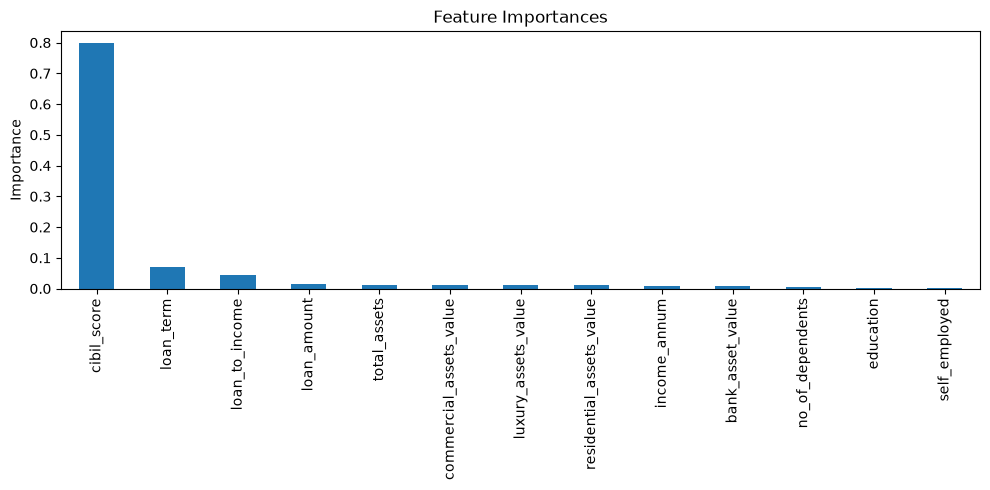

In [7]:
# random forest was way better on val so I'm tuning that
# keeping the grid small so this doesn't take forever
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("best params:", grid.best_params_)
print("cv acc:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\ntest acc:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

# sanity check: what is it actually using
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar')
plt.title('Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()